In [16]:
from evidently import Report
from evidently.presets import DataDriftPreset
import joblib
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [17]:
PROJECT_ROOT = Path("..")

X_train = joblib.load(PROJECT_ROOT / "data" / "X_train.pkl")

logs = pd.read_json(
    "logs/production_logs.jsonl",
    lines=True
)

production_data = pd.json_normalize(logs["features"])

production_data = production_data.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Données de référence :", X_train.shape)
print("Données de production simulées :", production_data.shape)

production_data.head()

Données de référence : (246008, 304)
Données de production simulées : (100, 304)


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,...,FONDKAPREMONT_MODE_reg_oper_spec_account,HOUSETYPE_MODE_specific_housing,HOUSETYPE_MODE_terraced_house,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,WALLSMATERIAL_MODE_Stone_brick,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_Yes
0,0.0,225000.0,900000.0,35694.0,900000.0,0.018634,-8576.0,-4332.0,7.0,1.0,...,False,False,False,False,False,False,True,False,False,False
1,0.0,180000.0,545040.0,25537.5,450000.0,0.030755,-4592.0,-520.0,9.0,1.0,...,False,False,False,False,False,False,True,False,False,False
2,2.0,135000.0,824823.0,24246.0,688500.0,0.006207,-1690.0,-4488.0,9.0,1.0,...,False,False,False,False,False,False,True,False,False,False
3,0.0,157500.0,225000.0,15034.5,225000.0,0.024610,-1219.0,-4218.0,12.0,1.0,...,False,False,False,False,False,False,True,False,False,False
4,0.0,144000.0,770292.0,32764.5,688500.0,0.031329,-3108.0,-1413.0,9.0,1.0,...,False,False,False,False,False,False,True,False,False,False


### Comparaison des distributions sur quelques variables

In [18]:
variables = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_REGISTRATION"
]

X_train[variables].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,246008.0,168853.180699,258960.632250,25650.0,112500.0,147600.0,202500.0,117000000.0
AMT_CREDIT,246008.0,599338.249368,402725.773305,45000.0,270000.0,514777.5,808650.0,4050000.0
AMT_ANNUITY,246008.0,27108.000073,14520.615758,1615.5,16510.5,24903.0,34596.0,258025.5
DAYS_REGISTRATION,246008.0,-4989.585005,3524.557231,-24672.0,-7480.0,-4505.0,-2015.0,0.0


In [19]:
production_data[variables].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,100.0,173537.460,88553.285470,36000.0,112500.000,157500.00,225000.0,450000.0
AMT_CREDIT,100.0,582785.820,419658.298336,61263.0,270000.000,521280.00,766323.0,2377431.0
AMT_ANNUITY,100.0,25248.465,12841.372593,4707.0,15908.625,23960.25,31203.0,70191.0
DAYS_REGISTRATION,100.0,-4844.330,3772.243547,-16820.0,-7304.500,-4417.50,-1427.0,-209.0


Les moyennes et les quartiles restent globalement proches pour les variables étudiées mais ces statistiques descriptives ne permettent pas de conclure à l'absence de data drift. Une analyse statistique plus complète est nécessaire.

### Détection de drift avec Evidently 

In [24]:
report = Report(
    metrics=[
        DataDriftPreset()
    ]
)

rapport_evidently = report.run(
    reference_data=X_train,
    current_data=production_data
)

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning:

invalid value encountered in divide

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

c:\Users\ocean\Documents\Credit-Scoring\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning:

invalid value encountered in divide



In [25]:
REPORT_PATH = PROJECT_ROOT / "reports" / "evidently_data_drift_report.html"

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

rapport_evidently.save_html(str(REPORT_PATH))

print(f"Rapport Evidently sauvegardé ici : {REPORT_PATH}")

Rapport Evidently sauvegardé ici : ..\reports\evidently_data_drift_report.html


### Analyse du PSI

In [ ]:
def calculate_psi(reference, current, buckets=10):
    """
    Calcule le Population Stability Index entre une variable de référence et une variable observée en production.
    """

    epsilon = 1e-4

    reference = pd.Series(reference).replace([np.inf, -np.inf], np.nan).dropna()
    current = pd.Series(current).replace([np.inf, -np.inf], np.nan).dropna()

    # Conversion des booléens en 0/1 pour permettre le calcul du PSI
    if reference.dtype == "bool":
        reference = reference.astype(int)

    if current.dtype == "bool":
        current = current.astype(int)

    # Valeurs en numérique
    reference = pd.to_numeric(reference, errors="coerce").dropna()
    current = pd.to_numeric(current, errors="coerce").dropna()

    if reference.empty or current.empty:
        return np.nan

    # Création des intervalles
    bornes = np.percentile(reference, np.linspace(0, 100, buckets + 1))
    bornes = np.unique(bornes)

    # Si la variable contient trop peu de valeurs différentes, le PSI n'est pas calculable
    if len(bornes) <= 2:
        return np.nan

    # Répartition des observations dans chaque intervalle
    distribution_reference = (
        pd.cut(reference, bins=bornes, include_lowest=True)
        .value_counts(normalize=True)
    )

    distribution_production = (
        pd.cut(current, bins=bornes, include_lowest=True)
        .value_counts(normalize=True)
    )

    psi = 0

    for intervalle in distribution_reference.index:
        proportion_reference = distribution_reference.get(intervalle, epsilon)
        proportion_production = distribution_production.get(intervalle, epsilon)

        proportion_reference = max(proportion_reference, epsilon)
        proportion_production = max(proportion_production, epsilon)

        psi += (
            (proportion_production - proportion_reference)
            * np.log(proportion_production / proportion_reference)
        )

    return psi


def interpret_psi(psi):
    if pd.isna(psi):
        return "Non calculable"
    elif psi < 0.1:
        return "Stable"
    elif psi < 0.2:
        return "Drift modéré à surveiller"
    else:
        return "Drift significatif - réentraînement à envisager"

In [ ]:
resultats_psi = []

for colonne in X_train.columns:
    psi = calculate_psi(
        reference=X_train[colonne],
        current=production_data[colonne]
    )

    resultats_psi.append({
        "Variable": colonne,
        "PSI": round(psi, 4) if not pd.isna(psi) else np.nan,
        "Interprétation": interpret_psi(psi)
    })

tableau_psi = (
    pd.DataFrame(resultats_psi)
    .sort_values("PSI", ascending=False)
    .reset_index(drop=True)
)

tableau_psi

,Variable,PSI,Interprétation
0,FLOORSMAX_MODE,7.5023,Drift significatif - réentraînement à envisager
1,FLOORSMAX_MEDI,7.4150,Drift significatif - réentraînement à envisager
2,FLOORSMAX_AVG,7.3485,Drift significatif - réentraînement à envisager
3,BASEMENTAREA_AVG,5.4793,Drift significatif - réentraînement à envisager
4,BASEMENTAREA_MEDI,5.4362,Drift significatif - réentraînement à envisager
...,...,...,...
299,WALLSMATERIAL_MODE_Others,NaN,Non calculable
300,WALLSMATERIAL_MODE_Panel,NaN,Non calculable
301,WALLSMATERIAL_MODE_Stone_brick,NaN,Non calculable
302,WALLSMATERIAL_MODE_Wooden,NaN,Non calculable


In [ ]:
# Variables qui nécessitent une surveillance
variables_a_surveiller = tableau_psi[
    tableau_psi["PSI"] >= 0.2
]

variables_a_surveiller

,Variable,PSI,Interprétation
0,FLOORSMAX_MODE,7.5023,Drift significatif - réentraînement à envisager
1,FLOORSMAX_MEDI,7.4150,Drift significatif - réentraînement à envisager
2,FLOORSMAX_AVG,7.3485,Drift significatif - réentraînement à envisager
3,BASEMENTAREA_AVG,5.4793,Drift significatif - réentraînement à envisager
4,BASEMENTAREA_MEDI,5.4362,Drift significatif - réentraînement à envisager
5,COMMONAREA_MODE,4.8444,Drift significatif - réentraînement à envisager
6,COMMONAREA_MEDI,4.8072,Drift significatif - réentraînement à envisager
7,CC_CNT_DRAWINGS_CURRENT_mean,4.4047,Drift significatif - réentraînement à envisager
8,YEARS_BUILD_MEDI,4.3080,Drift significatif - réentraînement à envisager
9,NONLIVINGAREA_MEDI,3.9932,Drift significatif - réentraînement à envisager


In [ ]:
resume_psi = tableau_psi["Interprétation"].value_counts().reset_index()
resume_psi.columns = ["Interprétation", "Nombre de variables"]

resume_psi

,Interprétation,Nombre de variables
0,Non calculable,170
1,Stable,99
2,Drift modéré à surveiller,20
3,Drift significatif - réentraînement à envisager,15


In [ ]:
# Top 10 des variables les plus instables
top_10_psi = tableau_psi.dropna(subset=["PSI"]).head(10)

top_10_psi

,Variable,PSI,Interprétation
0,FLOORSMAX_MODE,7.5023,Drift significatif - réentraînement à envisager
1,FLOORSMAX_MEDI,7.4150,Drift significatif - réentraînement à envisager
2,FLOORSMAX_AVG,7.3485,Drift significatif - réentraînement à envisager
3,BASEMENTAREA_AVG,5.4793,Drift significatif - réentraînement à envisager
4,BASEMENTAREA_MEDI,5.4362,Drift significatif - réentraînement à envisager
5,COMMONAREA_MODE,4.8444,Drift significatif - réentraînement à envisager
6,COMMONAREA_MEDI,4.8072,Drift significatif - réentraînement à envisager
7,CC_CNT_DRAWINGS_CURRENT_mean,4.4047,Drift significatif - réentraînement à envisager
8,YEARS_BUILD_MEDI,4.3080,Drift significatif - réentraînement à envisager
9,NONLIVINGAREA_MEDI,3.9932,Drift significatif - réentraînement à envisager


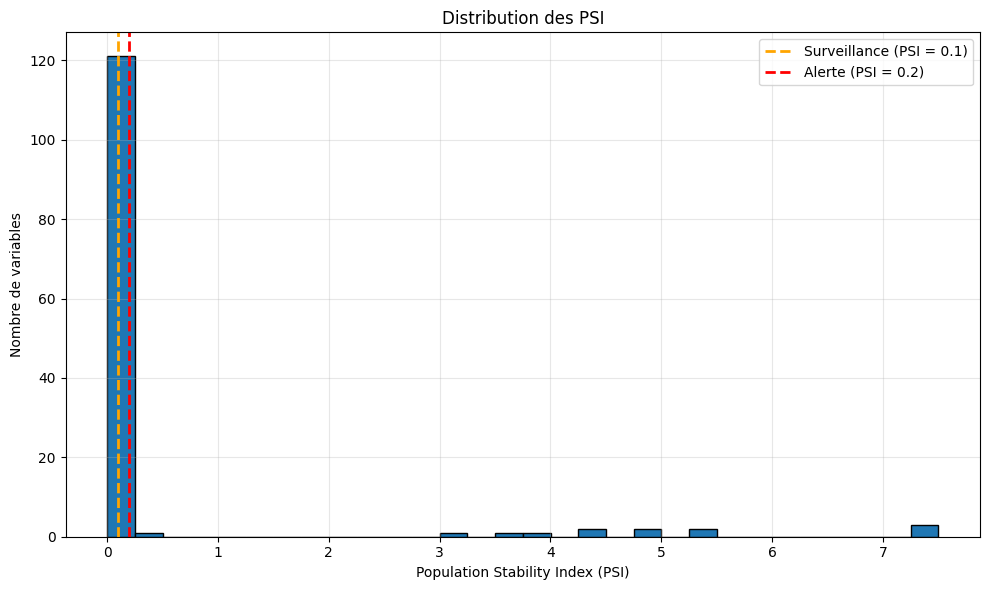

In [ ]:
# Vue globale
psi_valides = tableau_psi.dropna(subset=["PSI"])

plt.figure(figsize=(10, 6))

plt.hist(
    psi_valides["PSI"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    x=0.1,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Surveillance (PSI = 0.1)"
)

plt.axvline(
    x=0.2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Alerte (PSI = 0.2)"
)

plt.xlabel("Population Stability Index (PSI)")
plt.ylabel("Nombre de variables")
plt.title("Distribution des PSI")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

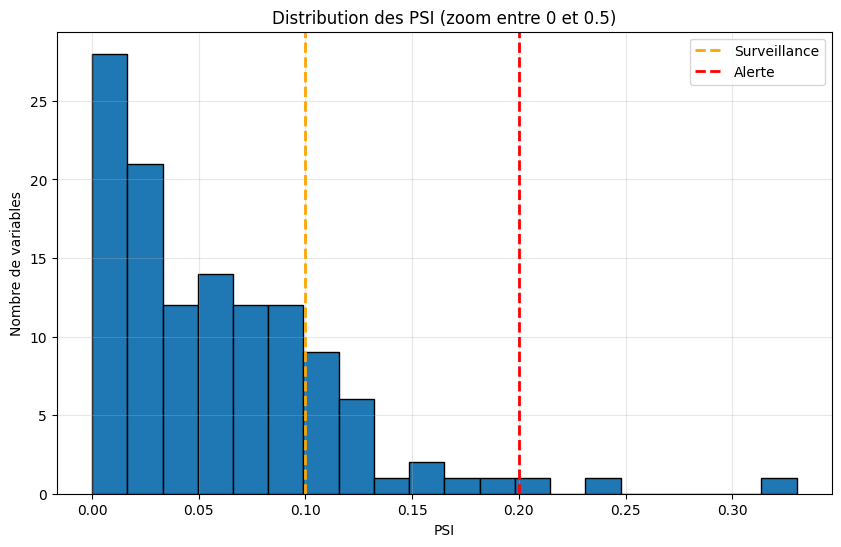

In [ ]:
# Vue zoomée

psi_zoom = psi_valides[psi_valides["PSI"] <= 0.5]

plt.figure(figsize=(10,6))

plt.hist(
    psi_zoom["PSI"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0.1,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Surveillance"
)

plt.axvline(
    0.2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Alerte"
)

plt.title("Distribution des PSI (zoom entre 0 et 0.5)")
plt.xlabel("PSI")
plt.ylabel("Nombre de variables")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

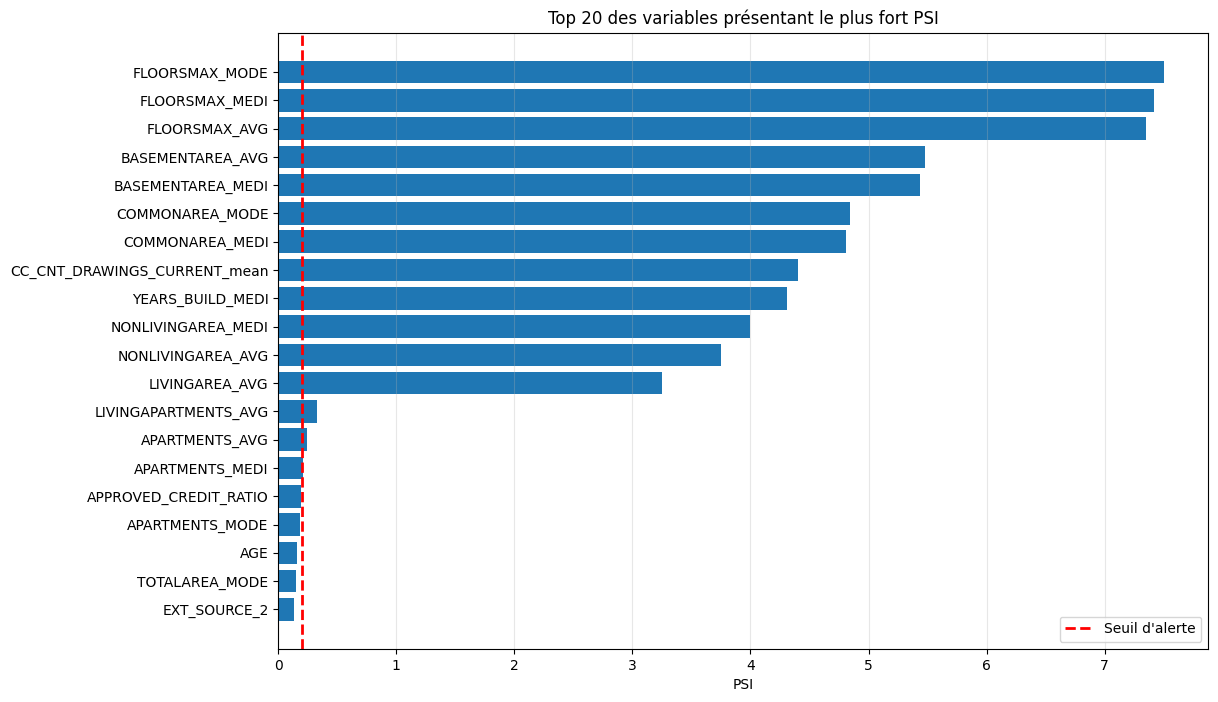

In [ ]:
top20 = (
    tableau_psi
    .dropna(subset=["PSI"])
    .head(20)
)

plt.figure(figsize=(12,8))

plt.barh(top20["Variable"], top20["PSI"])

plt.axvline(
    0.2,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Seuil d'alerte"
)

plt.xlabel("PSI")
plt.title("Top 20 des variables présentant le plus fort PSI")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.legend()

plt.show()